# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [3]:
from itertools import product
from tqdm.notebook import tqdm
from typing import Union

# 7.3) Forecasting a Non-stationary Time Series

In [4]:
df = pd.read_csv('data/jj.csv')

In [5]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [6]:
df.set_index('date', inplace=True)

In [7]:
df.index[np.arange(0, 84, 8)]

Index(['1960-01-01', '1962-01-01', '1964-01-01', '1966-01-01', '1968-01-01',
       '1970-01-01', '1972-01-01', '1974-01-01', '1976-01-01', '1978-01-01',
       '1980-01-01'],
      dtype='str', name='date')

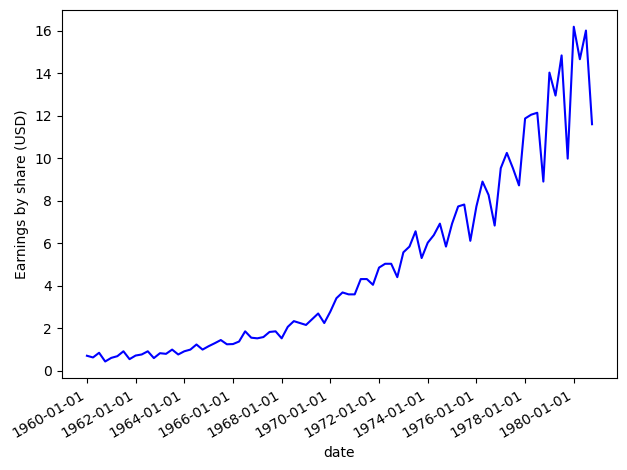

In [8]:
fig, ax = plt.subplots()
ax.plot(df['data'], 'b-')
ax.set_ylabel('Earnings by share (USD)')
ax.set_xlabel('date')
ax.set_xticks(df.index[np.arange(0, 84, 8)])
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [9]:
adfuller(df.iloc[:, 0])

(np.float64(2.742016573457479),
 1.0,
 11,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(82.63760283301104))

## Finding Integration Order

In [10]:
eps_diff = np.diff(df.iloc[:, 0], n=1)

In [11]:
adfuller(eps_diff)

(np.float64(-0.4074097636380444),
 np.float64(0.9088542416911309),
 10,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(89.21317134038202))

In [12]:
eps_diff2 = np.diff(df.iloc[:, 0], n=2)
adfuller(eps_diff2)

(np.float64(-3.5851628747932174),
 np.float64(0.006051099869602416),
 9,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(87.33900055833013))

## Train and test sets

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 84 entries, 1960-01-01 to 1980-10-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    84 non-null     float64
dtypes: float64(1)
memory usage: 3.4+ KB


In [14]:
df_train = df.loc[:"1980"]

In [15]:
df_train.shape

(80, 1)

In [16]:
df_train.tail()

,data
date,
1978-10-01,8.91
1979-01-01,14.04
1979-04-02,12.96
1979-07-02,14.85
1979-10-01,9.99


In [17]:
df_test = df.loc["1980":]

In [18]:
df_test.head()

,data
date,
1980-01-01,16.20
1980-04-01,14.67
1980-07-02,16.02
1980-10-01,11.61


In [19]:
df_test.shape

(4, 1)

## Finding MA and AR orders

In [20]:
def optimize_AIC(series: Union[pd.Series, list], order_list: list, d: int = 0) -> pd.DataFrame:
    """
    Compute AIC for each pair of (p, q) on order_list.

    Params:
    -------
    series: Unin[pd.Series, list]
        Univariate time series
    order_list: list
        list with bidimensional tuples with (p, q)
    d: int
        integration order. Defaults to 0.

    Returns:
    -------
        A dataframe with three columns: p, d, q, and AIC.
    """
    p = []
    q = []
    aic =[]

    for order in tqdm(order_list):
        try:
            model = SARIMAX(series, order=(order[0], d, order[1]), simple_differencing=False).fit(disp=False)
        except:
            continue
        p.append(order[0])
        q.append(order[1])
        aic.append(model.aic)

    return pd.DataFrame({
        'p': p, 'd': d, 'q': q, 'aic': aic
    }).sort_values(by='aic', ascending=True).reset_index(drop=True)
        

In [21]:
optimize_AIC(
    df_train.iloc[:, 0].values,
    order_list=list(product(np.arange(4), np.arange(4))),
    d=2
)

  0%|          | 0/16 [00:00<?, ?it/s]

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("M

,p,d,q,aic
0,3,2,3,115.267589
1,3,2,1,115.624981
2,3,2,2,115.672007
3,3,2,0,154.430637
4,0,2,3,194.654716
5,0,2,2,209.274472
6,2,2,3,220.666849
7,1,2,3,228.267788
8,1,2,2,228.935817
9,2,2,2,229.974666


## Fitting and GOF 

In [22]:
model_fit = SARIMAX(df_train.iloc[:, 0].values, order=(3, 2, 3), simple_differencing=False).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


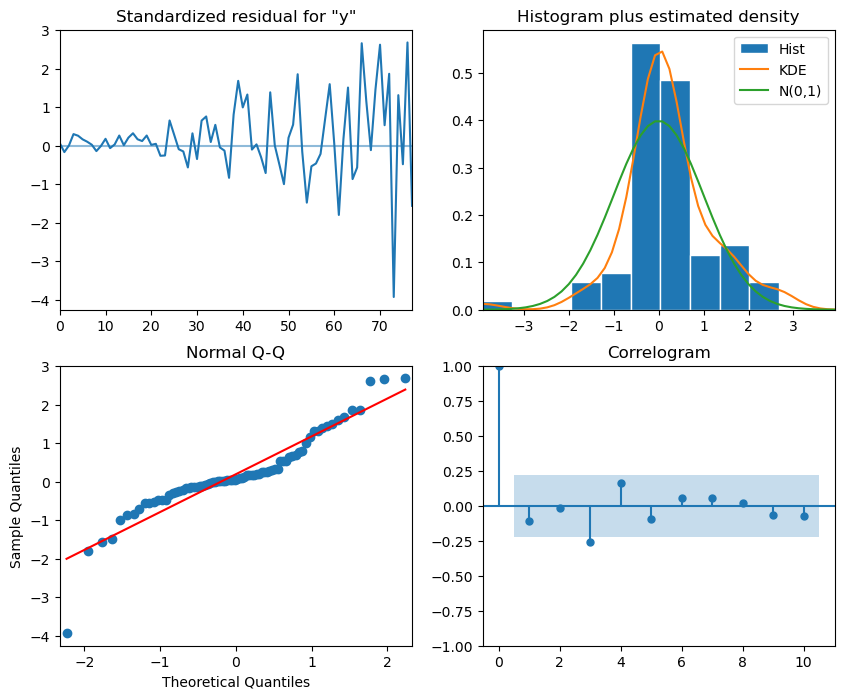

In [23]:
model_fit.plot_diagnostics(figsize=(10, 8));

In [24]:
residuals = model_fit.resid

In [25]:
ljung_box = acorr_ljungbox(residuals, np.arange(1, 11))

In [26]:
ljung_box.info()

<class 'pandas.DataFrame'>
Index: 10 entries, 1 to 10
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lb_stat    10 non-null     float64
 1   lb_pvalue  10 non-null     float64
dtypes: float64(2)
memory usage: 240.0 bytes


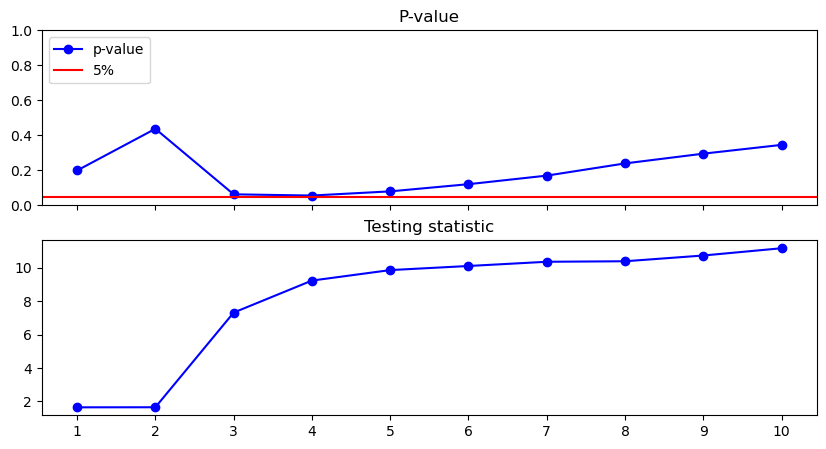

In [30]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 5), sharex=True)
ax[0].plot(ljung_box.lb_pvalue, 'b-o', label='p-value')
ax[0].set_ylim([0, 1])
ax[0].axhline(0.05, color='red', label='5%')
ax[0].legend(loc='upper left')
ax[0].set_xticks(np.arange(1, 11, 1))
ax[0].set_title('P-value')
ax[1].plot(ljung_box.lb_stat, 'b-o')
ax[1].set_title('Testing statistic')
plt.show()

## Forecasting

In [31]:
pred = model_fit.get_prediction(0, 83).predicted_mean

In [37]:
df_train.iloc[-4:, 0].values

array([14.04, 12.96, 14.85,  9.99])

In [43]:
df_pred = pd.DataFrame({
    'observed': df_test.iloc[:, 0].values,
    'seasonal_naive': df_train.iloc[-4:, 0].values,
    'arima': pred[-4:]
}, index=df_test.index)

In [44]:
df_pred

,observed,seasonal_naive,arima
date,,,
1980-01-01,16.20,14.04,15.857898
1980-04-01,14.67,12.96,14.384529
1980-07-02,16.02,14.85,16.369335
1980-10-01,11.61,9.99,11.680425


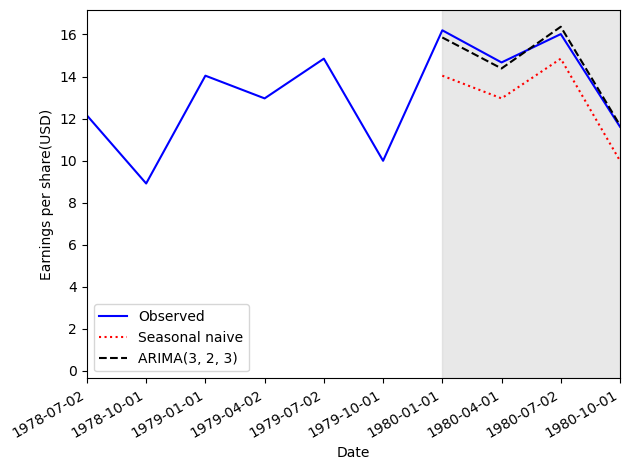

In [53]:
fig, ax = plt.subplots()
ax.plot(df, 'b-', label='Observed')
ax.plot(df_pred['seasonal_naive'], 'r:', label='Seasonal naive')
ax.plot(df_pred['arima'], 'k--', label='ARIMA(3, 2, 3)')
ax.set_xticks(df.index[np.arange(0, 84, 1)])
ax.set_xlim([df.index[-10], df.index[-1]])
ax.axvspan(df.index[-4], df.index[-1], color='lightgrey', alpha=0.5)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share(USD)')
ax.legend(loc='lower left')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## MAPE

In [77]:
mape = lambda y_true, y_pred: np.mean(np.abs((y_true  - y_pred) / y_true)) * 100

In [78]:
df_mape = pd.Series({
    'Seasonal naive': mape(df_pred['observed'], df_pred['seasonal_naive']),
    'ARIMA(3, 2, 3)': mape(df_pred['observed'], df_pred['arima'])
})

In [79]:
df_mape 

Seasonal naive    11.561659
ARIMA(3, 2, 3)     1.711224
dtype: float64

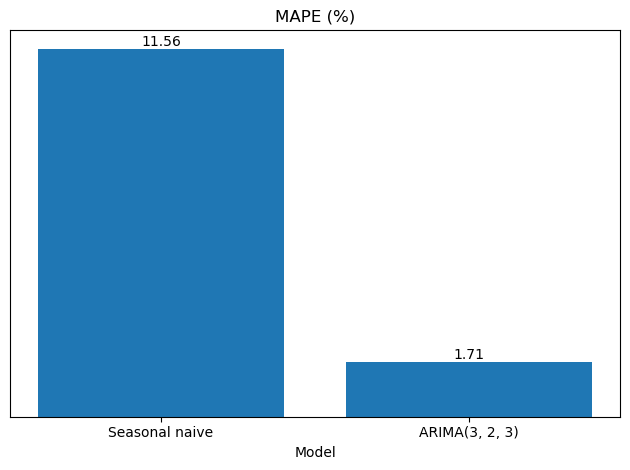

In [80]:
fig, ax = plt.subplots()
bar = ax.bar(df_mape.index, df_mape.values)
ax.bar_label(bar, fmt='%.2f')
ax.set_yticks([])
ax.set_xlabel('Model')
ax.set_title('MAPE (%)')
fig.tight_layout()
plt.show()